原始flux数组最大值: 1.066915902344071e+61
No=1 对应参数：
  lgm: 1.0
  alpha: 0.01
  lgm_dot: 0.4
No=50 对应参数：
  lgm: 1.0
  alpha: 0.01
  lgm_dot: 3.1
No=1000 对应参数：
  lgm: 2.0
  alpha: 0.03
  lgm_dot: 3.8
✅ 已保存图像: \\wsl.localhost\Ubuntu-22.04\home\hdw\data\naoc\EOTA\energy_spectrum_selected_no_rawflux.png


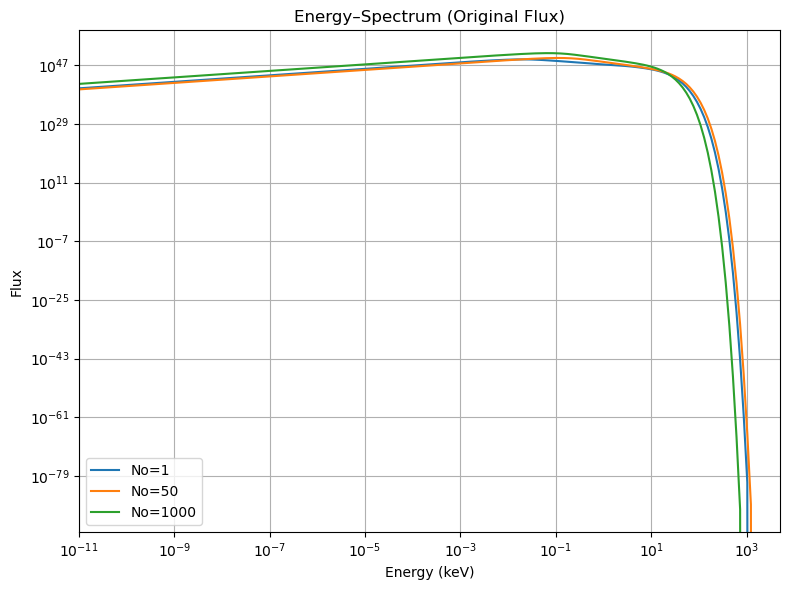

In [91]:
#!/usr/bin/env python3
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ====== 配置 ======
base_dir = os.path.expanduser(r"\\wsl.localhost\Ubuntu-22.04\home\hdw\data\naoc\EOTA")
spec_path = os.path.join(base_dir, "disk_spec_sorted.csv")
para_path = os.path.join(base_dir, "disk_para_sorted.csv")

# 你想画的 No 号（可以是多个）
plot_no_list = [1, 50, 1000]  # 修改这里选择要画的 No

# ====== 读取 CSV ======
spec_df = pd.read_csv(spec_path)
para_df = pd.read_csv(para_path)

# ====== 解析能量列 ======
energy_cols = spec_df.columns[1:]  # 第一列是 No
energy_vals = np.array([float(c) for c in energy_cols])

if not np.all(np.diff(energy_vals) > 0):
    print("⚠ 能量列不是严格递增！")

# ====== 取原始flux，过滤小于1e-12的值置0 ======
flux_array = np.array(spec_df.iloc[:, 1:], dtype=float)
flux_array[np.abs(flux_array) < 1e-100] = 0.0  # 小于阈值的置0

print(f"原始flux数组最大值: {flux_array.max()}")

# ====== 按 No 绘图并输出参数 ======
plt.figure(figsize=(8, 6))
for no_val in plot_no_list:
    row_idx = spec_df[spec_df["No"] == no_val].index
    if len(row_idx) == 0:
        print(f"⚠ 找不到 No={no_val}，跳过")
        continue

    flux = flux_array[row_idx[0], :]
    plt.plot(energy_vals, flux, label=f"No={no_val}")

    # 查找参数
    para_row = para_df[para_df["No"] == no_val]
    if para_row.empty:
        print(f"⚠ 参数文件中找不到 No={no_val}")
    else:
        print(f"No={no_val} 对应参数：")
        for col in para_row.columns:
            if col != "No":
                print(f"  {col}: {para_row.iloc[0][col]}")

# ====== 图形设置 ======
plt.xlabel("Energy (keV)")
plt.ylabel("Flux")
plt.xscale("log")
plt.yscale("log")
plt.xlim(1e-11, 5000)
plt.title("Energy–Spectrum (Original Flux)")
plt.legend()
plt.grid(True)
plt.tight_layout()

# 保存图像
out_path = os.path.join(base_dir, "energy_spectrum_selected_no_rawflux.png")
plt.savefig(out_path, dpi=300)
print(f"✅ 已保存图像: {out_path}")

plt.show()


## 所有spec统一归一化

全局最大 flux 值: 1.066915902344071e+61
No=1 对应参数：
  lgm: 1.0
  alpha: 0.01
  lgm_dot: 0.4
No=50 对应参数：
  lgm: 1.0
  alpha: 0.01
  lgm_dot: 3.1
No=1000 对应参数：
  lgm: 2.0
  alpha: 0.03
  lgm_dot: 3.8
✅ 已保存图像: \\wsl.localhost\Ubuntu-22.04\home\hdw\data\naoc\EOTA\energy_spectrum_selected_no.png


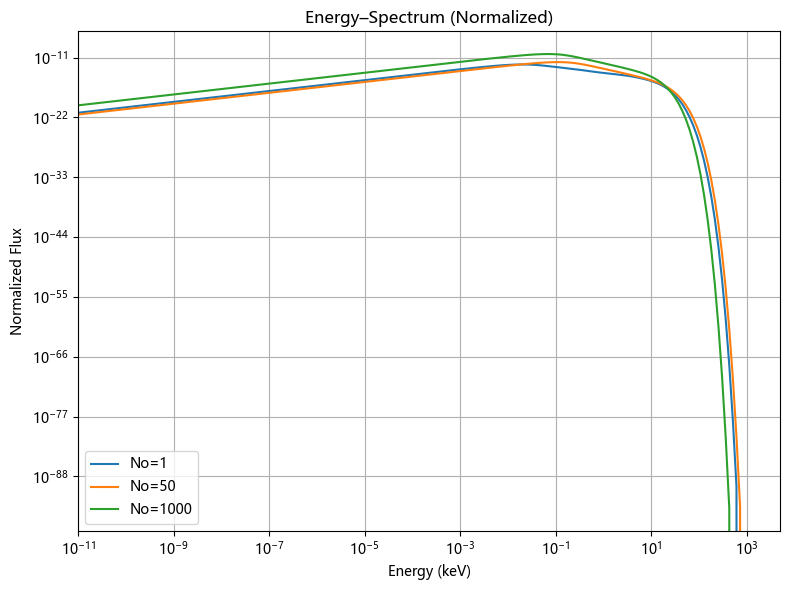

In [119]:
#!/usr/bin/env python3
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ====== 配置 ======
base_dir = os.path.expanduser(r"\\wsl.localhost\Ubuntu-22.04\home\hdw\data\naoc\EOTA")
spec_path = os.path.join(base_dir, "disk_spec_sorted.csv")
para_path = os.path.join(base_dir, "disk_para_sorted.csv")

# 你想画的 No 号（可以是多个）
plot_no_list = [1, 50, 1000]  # 修改这里选择要画的 No

# ====== 读取 CSV ======
spec_df = pd.read_csv(spec_path)
para_df = pd.read_csv(para_path)

# ====== 解析能量列 ======
energy_cols = spec_df.columns[1:]  # 第一列是 No
energy_vals = np.array([float(c) for c in energy_cols])

if not np.all(np.diff(energy_vals) > 0):
    print("⚠ 能量列不是严格递增！")

# ====== 全局归一化 ======
flux_array = np.array(spec_df.iloc[:, 1:], dtype=float)
max_flux_value = flux_array.max()
flux_array_norm = flux_array / max_flux_value if max_flux_value > 0 else flux_array

# ====== 归一化后再去除 <1e-12 ======
flux_array_norm[np.abs(flux_array_norm) < 1e-100] = 0.0

print(f"全局最大 flux 值: {max_flux_value}")

# ====== 按 No 绘图并输出参数 ======
plt.figure(figsize=(8, 6))
for no_val in plot_no_list:
    row_idx = spec_df[spec_df["No"] == no_val].index
    if len(row_idx) == 0:
        print(f"⚠ 找不到 No={no_val}，跳过")
        continue

    flux_norm = flux_array_norm[row_idx[0], :]
    plt.plot(energy_vals, flux_norm, label=f"No={no_val}")

    # 查找参数
    para_row = para_df[para_df["No"] == no_val]
    if para_row.empty:
        print(f"⚠ 参数文件中找不到 No={no_val}")
    else:
        print(f"No={no_val} 对应参数：")
        for col in para_row.columns:
            if col != "No":
                print(f"  {col}: {para_row.iloc[0][col]}")

# ====== 图形设置 ======
plt.xlabel("Energy (keV)")
plt.ylabel("Normalized Flux")
plt.xscale("log")
plt.yscale("log")
plt.xlim(1e-11, 5000)
plt.title("Energy–Spectrum (Normalized)")
plt.legend()
plt.grid(True)
plt.tight_layout()

# 保存图像
out_path = os.path.join(base_dir, "energy_spectrum_selected_no.png")
plt.savefig(out_path, dpi=300)
print(f"✅ 已保存图像: {out_path}")

plt.show()


全局最大 flux 值: 1.066915902344071e+61
No=1 对应参数（QDP叠加图）:
  lgm: 1.0
  alpha: 0.01
  lgm_dot: 0.4
No=50 对应参数（QDP叠加图）:
  lgm: 1.0
  alpha: 0.01
  lgm_dot: 3.1
No=1000 对应参数（QDP叠加图）:
  lgm: 2.0
  alpha: 0.03
  lgm_dot: 3.8
✅ 已保存图像: \\wsl.localhost\Ubuntu-22.04\home\hdw\data\naoc\EOTA\energy_spectrum_selected_no_compare_qdp.png


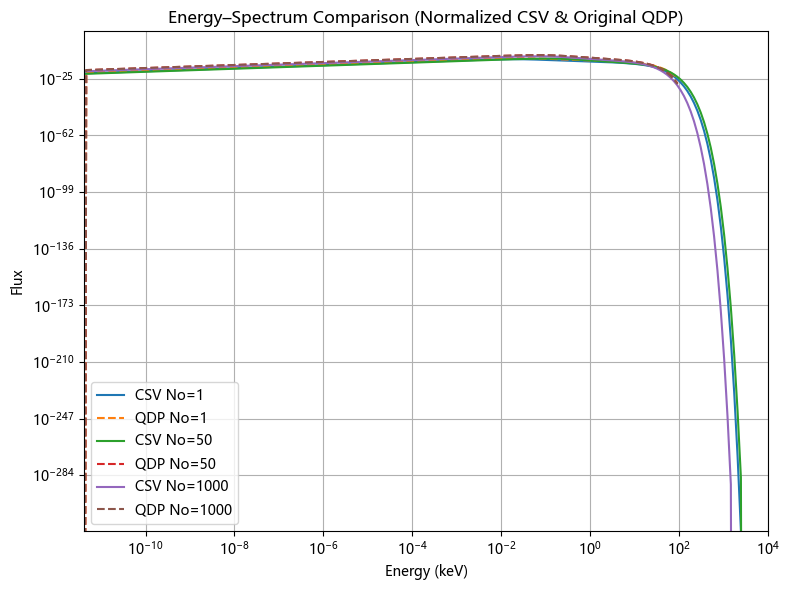

In [123]:
#!/usr/bin/env python3
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ====== 配置 ======
base_dir = os.path.expanduser(r"\\wsl.localhost\Ubuntu-22.04\home\hdw\data\naoc\EOTA")
spec_path = os.path.join(base_dir, "disk_spec_sorted.csv")
para_path = os.path.join(base_dir, "disk_para_sorted.csv")

# 你想画的 No 号（可以是多个）
plot_no_list = [1,50, 1000]  # 修改这里选择要画的 No

# ====== 读取 CSV ======
spec_df = pd.read_csv(spec_path)
para_df = pd.read_csv(para_path)

# ====== 解析能量列 ======
energy_cols = spec_df.columns[1:]  # 第一列是 No
energy_vals = np.array([float(c) for c in energy_cols])

if not np.all(np.diff(energy_vals) > 0):
    print("⚠ 能量列不是严格递增！")

# ====== 全局归一化 ======
flux_array = np.array(spec_df.iloc[:, 1:], dtype=float)
max_flux_value = flux_array.max()
flux_array_norm = flux_array / max_flux_value if max_flux_value > 0 else flux_array

print(f"全局最大 flux 值: {max_flux_value}")

# ====== QDP 文件读取函数，读取第一列（x）和第三列（flux） ======
def read_qdp_xy(qdp_path):
    """
    读取 QDP 文件中的第一列（x）和第三列（flux）数据，返回两个 numpy 数组
    忽略注释和指令行
    """
    x_data = []
    y_data = []
    if not os.path.exists(qdp_path):
        print(f"⚠ QDP文件不存在: {qdp_path}")
        return None, None
    with open(qdp_path, 'r') as f:
        for line in f:
            if line.startswith(('!', '@', 'READ')):
                continue
            parts = line.strip().split()
            if len(parts) < 3:
                continue
            try:
                x = float(parts[0])
                y = float(parts[2])
                x_data.append(x)
                y_data.append(y)
            except ValueError:
                continue
    return np.array(x_data), np.array(y_data)

# ====== 叠加绘图 ======
plt.figure(figsize=(8, 6))

for no_val in plot_no_list:
    row_idx = spec_df[spec_df["No"] == no_val].index
    if len(row_idx) == 0:
        print(f"⚠ 找不到 No={no_val}，跳过")
        continue

    # CSV归一化flux
    flux_norm = flux_array_norm[row_idx[0], :]
    plt.plot(energy_vals, flux_norm, label=f"CSV No={no_val}")

    # 读取对应QDP文件的x和y
    qdp_file = os.path.join(base_dir, f"no{no_val}.qdp")
    qdp_x, qdp_flux = read_qdp_xy(qdp_file)

    if qdp_flux is not None and qdp_x is not None:
        if len(qdp_flux) != len(qdp_x):
            print(f"⚠ No={no_val} QDP数据x和y长度不匹配，跳过QDP绘图")
        else:
            plt.plot(qdp_x, qdp_flux, label=f"QDP No={no_val}", linestyle='--')

    # 输出参数信息
    para_row = para_df[para_df["No"] == no_val]
    if para_row.empty:
        print(f"⚠ 参数文件中找不到 No={no_val}")
    else:
        print(f"No={no_val} 对应参数（QDP叠加图）:")
        for col in para_row.columns:
            if col != "No":
                print(f"  {col}: {para_row.iloc[0][col]}")

# 图形设置
plt.xlabel("Energy (keV)")
plt.ylabel("Flux")
plt.xscale("log")
plt.yscale("log")
plt.xlim(energy_vals.min(), 10000)
plt.title("Energy–Spectrum Comparison (Normalized CSV & Original QDP)")
plt.legend()
plt.grid(True)
plt.tight_layout()

# 保存图像
out_path_qdp = os.path.join(base_dir, "energy_spectrum_selected_no_compare_qdp.png")
plt.savefig(out_path_qdp, dpi=300)
print(f"✅ 已保存图像: {out_path_qdp}")

plt.show()


✅ 已保存比例图像: \\wsl.localhost\Ubuntu-22.04\home\hdw\data\naoc\EOTA\ratio_qdp_csv.png


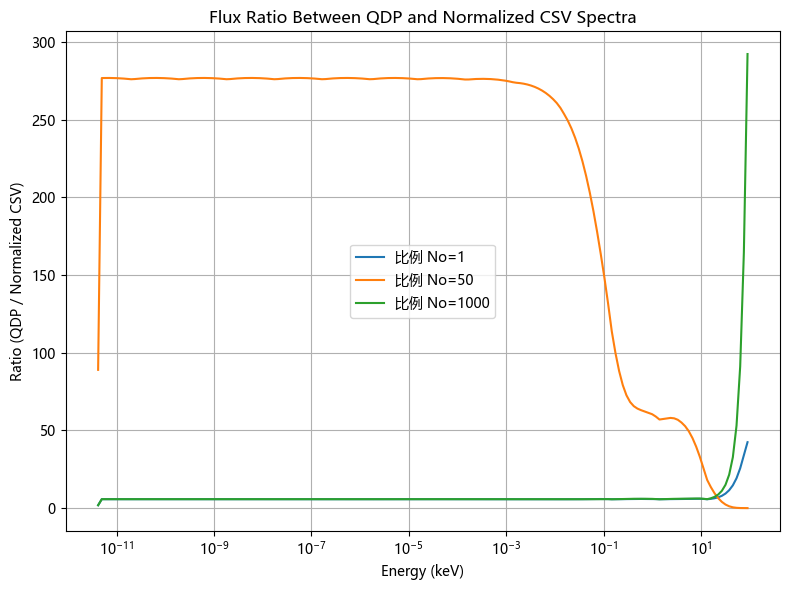

In [131]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# 假设这些变量你之前都定义好了：
# base_dir, plot_no_list, spec_df, para_df, flux_array_norm, energy_vals
# 并且 read_qdp_xy(qdp_path) 函数已经定义好，能返回 (x_array, y_array)

plt.figure(figsize=(8, 6))

for no_val in plot_no_list:
    row_idx = spec_df[spec_df["No"] == no_val].index
    if len(row_idx) == 0:
        print(f"⚠ 找不到 No={no_val}，跳过")
        continue

    # 归一化 CSV flux
    flux_norm = flux_array_norm[row_idx[0], :]

    # 读取对应 QDP 文件的 x 和 y
    qdp_file = os.path.join(base_dir, f"no{no_val}.qdp")
    qdp_x, qdp_flux = read_qdp_xy(qdp_file)

    if qdp_flux is not None and qdp_x is not None:
        if len(qdp_flux) != len(qdp_x):
            print(f"⚠ No={no_val} QDP数据x和y长度不匹配，跳过比例绘图")
            continue

        # 对 QDP flux 在 CSV 能量点做对数插值
        valid_mask = (energy_vals >= qdp_x.min()) & (energy_vals <= qdp_x.max())
        interp_func = interp1d(np.log10(qdp_x), qdp_flux, kind='linear', bounds_error=False, fill_value=np.nan)
        qdp_flux_interp = np.full_like(energy_vals, np.nan, dtype=float)
        qdp_flux_interp[valid_mask] = interp_func(np.log10(energy_vals[valid_mask]))

        # 计算比例 (QDP_flux / CSV_flux)
        # 避免除以零，用nan替代
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = np.where(flux_norm != 0, qdp_flux_interp / flux_norm, np.nan)

        plt.plot(energy_vals[valid_mask], ratio[valid_mask], label=f"比例 No={no_val}")

    else:
        print(f"⚠ No={no_val} 缺少QDP数据，跳过比例绘图")

plt.xlabel("Energy (keV)")
plt.ylabel("Ratio (QDP / Normalized CSV)")
plt.xscale("log")
plt.yscale("linear")
plt.title("Flux Ratio Between QDP and Normalized CSV Spectra")
plt.legend()
plt.grid(True)
plt.tight_layout()

out_path_ratio = os.path.join(base_dir, "ratio_qdp_csv.png")
plt.savefig(out_path_ratio, dpi=300)
print(f"✅ 已保存比例图像: {out_path_ratio}")

plt.show()


## 每组spec分别归一化

全局最大 flux 值: 1.066915902344071e+61
No=1 对应参数：
  lgm: 1.0
  alpha: 0.01
  lgm_dot: 0.4
No=50 对应参数：
  lgm: 1.0
  alpha: 0.01
  lgm_dot: 3.1
No=1000 对应参数：
  lgm: 2.0
  alpha: 0.03
  lgm_dot: 3.8
✅ 已保存图像: \\wsl.localhost\Ubuntu-22.04\home\hdw\data\naoc\EOTA\energy_spectrum_selected_no_single_norm.png


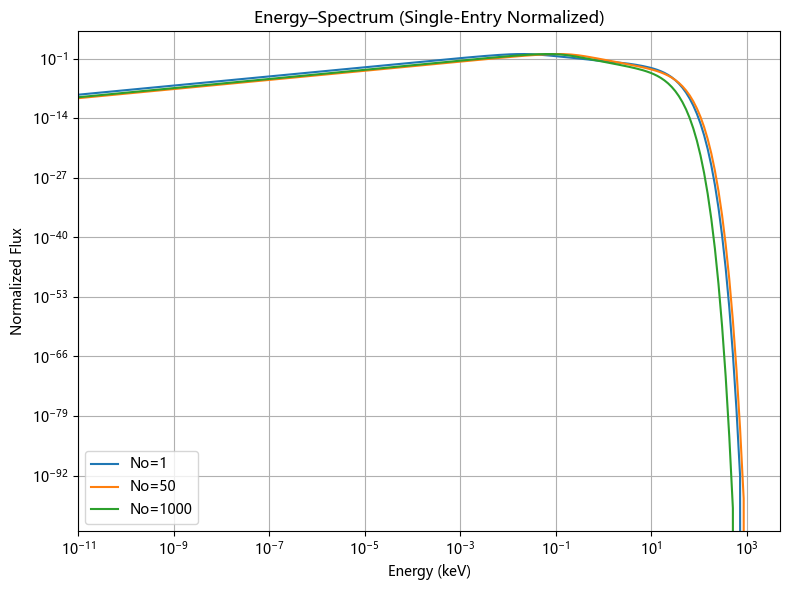

In [133]:
#!/usr/bin/env python3
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ====== 配置 ======
base_dir = os.path.expanduser(r"\\wsl.localhost\Ubuntu-22.04\home\hdw\data\naoc\EOTA")
spec_path = os.path.join(base_dir, "disk_spec_sorted.csv")
para_path = os.path.join(base_dir, "disk_para_sorted.csv")

# 你想画的 No 号（可以是多个）
plot_no_list = [1, 50, 1000]  # 修改这里选择要画的 No

# ====== 读取 CSV ======
spec_df = pd.read_csv(spec_path)
para_df = pd.read_csv(para_path)

# ====== 解析能量列 ======
energy_cols = spec_df.columns[1:]  # 第一列是 No
energy_vals = np.array([float(c) for c in energy_cols])

if not np.all(np.diff(energy_vals) > 0):
    print("⚠ 能量列不是严格递增！")

# ====== 按 No 读取flux并单条归一化 ======
flux_norm_dict = {}  # 存储每个No对应归一化后的flux
max_flux_list = []

for idx, row in spec_df.iterrows():
    no = row["No"]
    flux = np.array(row[1:], dtype=float)
    max_flux = flux.max()
    max_flux_list.append(max_flux)
    if max_flux > 0:
        flux_norm_dict[no] = flux / max_flux
    else:
        flux_norm_dict[no] = flux

# 全局最大flux（未归一化）
global_max_flux = max(max_flux_list)
print(f"全局最大 flux 值: {global_max_flux}")

# ====== 绘图 ======
plt.figure(figsize=(8, 6))
for no_val in plot_no_list:
    if no_val not in flux_norm_dict:
        print(f"⚠ 找不到 No={no_val}，跳过")
        continue
    flux_norm = flux_norm_dict[no_val]
    # 小于阈值置零
    flux_norm[np.abs(flux_norm) < 1e-100] = 0.0
    plt.plot(energy_vals, flux_norm, label=f"No={no_val}")

    # 查找参数
    para_row = para_df[para_df["No"] == no_val]
    if para_row.empty:
        print(f"⚠ 参数文件中找不到 No={no_val}")
    else:
        print(f"No={no_val} 对应参数：")
        for col in para_row.columns:
            if col != "No":
                print(f"  {col}: {para_row.iloc[0][col]}")

# ====== 图形设置 ======
plt.xlabel("Energy (keV)")
plt.ylabel("Normalized Flux")
plt.xscale("log")
plt.yscale("log")
plt.xlim(1e-11, 5000)
plt.title("Energy–Spectrum (Single-Entry Normalized)")
plt.legend()
plt.grid(True)
plt.tight_layout()

# 保存图像
out_path = os.path.join(base_dir, "energy_spectrum_selected_no_single_norm.png")
plt.savefig(out_path, dpi=300)
print(f"✅ 已保存图像: {out_path}")

plt.show()


全局最大 flux 值（未用于归一化）: 1.066915902344071e+61
No=7000 归一化Flux前20点:
6.574729e-09 7.820865e-09 9.303185e-09 1.106646e-08 1.316393e-08 1.565894e-08 1.862684e-08 2.215726e-08 2.635682e-08 3.135233e-08 3.729467e-08 4.436328e-08 5.277163e-08 6.277365e-08 7.467140e-08 8.882417e-08 1.056594e-07 1.256854e-07 1.495071e-07 1.778438e-07
No=7000 对应参数（QDP叠加图）:
  lgm: 9.0
  alpha: 0.08
  lgm_dot: 3.8
✅ 已保存图像: \\wsl.localhost\Ubuntu-22.04\home\hdw\data\naoc\EOTA\energy_spectrum_selected_no_compare_qdp_single_norm.png


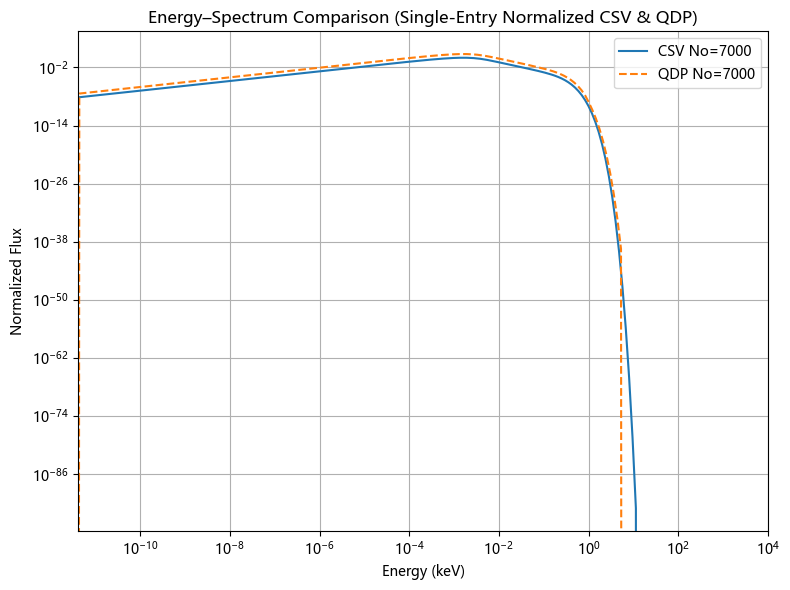

In [169]:
#!/usr/bin/env python3
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ====== 配置 ======
base_dir = os.path.expanduser(r"\\wsl.localhost\Ubuntu-22.04\home\hdw\data\naoc\EOTA")
spec_path = os.path.join(base_dir, "disk_spec_sorted.csv")
para_path = os.path.join(base_dir, "disk_para_sorted.csv")

# 你想画的 No 号（可以是多个）
plot_no_list = [7000]  # 修改这里选择要画的 No

# ====== 读取 CSV ======
spec_df = pd.read_csv(spec_path)
para_df = pd.read_csv(para_path)

# ====== 解析能量列 ======
energy_cols = spec_df.columns[1:]  # 第一列是 No
energy_vals = np.array([float(c) for c in energy_cols])

if not np.all(np.diff(energy_vals) > 0):
    print("⚠ 能量列不是严格递增！")

# ====== 按 No 读取flux并单条归一化 ======
flux_norm_dict = {}  # 存储每个No对应归一化后的flux
max_flux_list = []

for idx, row in spec_df.iterrows():
    no = row["No"]
    flux = np.array(row[1:], dtype=float)
    max_flux = flux.max()
    max_flux_list.append(max_flux)
    if max_flux > 0:
        flux_norm_dict[no] = flux / max_flux
    else:
        flux_norm_dict[no] = flux

# 全局最大flux（未归一化），仅打印参考
global_max_flux = max(max_flux_list)
print(f"全局最大 flux 值（未用于归一化）: {global_max_flux}")

# ====== QDP 文件读取函数，读取第一列（x）和第三列（flux） ======
def read_qdp_xy(qdp_path):
    """
    读取 QDP 文件中的第一列（x）和第三列（flux）数据，返回两个 numpy 数组
    忽略注释和指令行
    """
    x_data = []
    y_data = []
    if not os.path.exists(qdp_path):
        print(f"⚠ QDP文件不存在: {qdp_path}")
        return None, None
    with open(qdp_path, 'r') as f:
        for line in f:
            if line.startswith(('!', '@', 'READ')):
                continue
            parts = line.strip().split()
            if len(parts) < 3:
                continue
            try:
                x = float(parts[0])
                y = float(parts[2])
                x_data.append(x)
                y_data.append(y)
            except ValueError:
                continue
    return np.array(x_data), np.array(y_data)

# ====== 叠加绘图 ======
plt.figure(figsize=(8, 6))

for no_val in plot_no_list:
    if no_val not in flux_norm_dict:
        print(f"⚠ 找不到 No={no_val}，跳过")
        continue

    # 取单条归一化flux绘图
    flux_norm = flux_norm_dict[no_val]
    # 过滤极小值
    flux_norm[np.abs(flux_norm) < 1e-100] = 0.0

    # 打印归一化flux前20点
    print(f"No={no_val} 归一化Flux前20点:")
    print(" ".join(f"{v:.6e}" for v in flux_norm[:20]))

    plt.plot(energy_vals, flux_norm, label=f"CSV No={no_val}")

    # 读取对应QDP文件，文件名格式 no{no_val}_norm.qdp
    qdp_file = os.path.join(base_dir, f"no{no_val}_norm.qdp")
    qdp_x, qdp_flux = read_qdp_xy(qdp_file)

    if qdp_flux is not None and qdp_x is not None:
        if len(qdp_flux) != len(qdp_x):
            print(f"⚠ No={no_val} QDP数据x和y长度不匹配，跳过QDP绘图")
        else:
            plt.plot(qdp_x, qdp_flux, label=f"QDP No={no_val}", linestyle='--')

    # 输出参数信息
    para_row = para_df[para_df["No"] == no_val]
    if para_row.empty:
        print(f"⚠ 参数文件中找不到 No={no_val}")
    else:
        print(f"No={no_val} 对应参数（QDP叠加图）:")
        for col in para_row.columns:
            if col != "No":
                print(f"  {col}: {para_row.iloc[0][col]}")

# ====== 图形设置 ======
plt.xlabel("Energy (keV)")
plt.ylabel("Normalized Flux")
plt.xscale("log")
plt.yscale("log")
plt.xlim(energy_vals.min(), 10000)
plt.title("Energy–Spectrum Comparison (Single-Entry Normalized CSV & QDP)")
plt.legend()
plt.grid(True)
plt.tight_layout()

# 保存图像
out_path_qdp = os.path.join(base_dir, "energy_spectrum_selected_no_compare_qdp_single_norm.png")
plt.savefig(out_path_qdp, dpi=300)
print(f"✅ 已保存图像: {out_path_qdp}")

plt.show()


[4.15265705e+00 5.75252357e+00 5.75376472e+00 5.75437335e+00
 5.75433634e+00 5.75363970e+00 5.75226885e+00 5.75020973e+00
 5.74744766e+00 5.74396755e+00 5.73975483e+00 5.73479433e+00
 5.73098031e+00 5.73590644e+00 5.74028142e+00 5.74409297e+00
 5.74732944e+00 5.74997674e+00 5.75202234e+00 5.75345328e+00
 5.75425608e+00 5.75441704e+00 5.75392252e+00 5.75275830e+00
 5.75091006e+00 5.74836363e+00 5.74510398e+00 5.74111628e+00
 5.73638445e+00 5.73089425e+00 5.73446511e+00 5.73900891e+00
 5.74299365e+00 5.74640575e+00 5.74923382e+00 5.75146428e+00
 5.75308382e+00 5.75407914e+00 5.75443682e+00 5.75414320e+00
 5.75318442e+00 5.75154609e+00 5.74921320e+00 5.74617049e+00
 5.74240791e+00 5.73790442e+00 5.73264687e+00 5.73297252e+00
 5.73768420e+00 5.74184041e+00 5.74542791e+00 5.74843458e+00
 5.75084742e+00 5.75265408e+00 5.75384048e+00 5.75439327e+00
 5.75429890e+00 5.75354349e+00 5.75211338e+00 5.74999397e+00
 5.74717037e+00 5.74362860e+00 5.73935350e+00 5.73432997e+00
 5.73143262e+00 5.736302

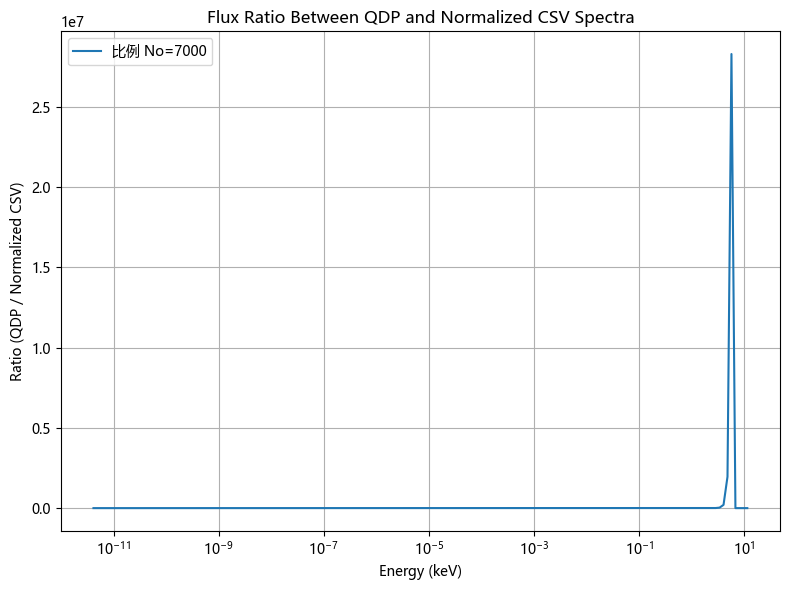

In [173]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# 假设这些变量你之前都定义好了：
# base_dir, plot_no_list, spec_df, para_df, flux_norm_dict, energy_vals
# 并且 read_qdp_xy(qdp_path) 函数已经定义好，能返回 (x_array, y_array)

plt.figure(figsize=(8, 6))

for no_val in plot_no_list:
    if no_val not in flux_norm_dict:
        print(f"⚠ 找不到 No={no_val} 的归一化 flux，跳过")
        continue

    flux_norm = flux_norm_dict[no_val]

    # 读取对应 QDP 文件，文件名格式 no{no_val}_norm.qdp
    qdp_file = os.path.join(base_dir, f"no{no_val}_norm.qdp")
    qdp_x, qdp_flux = read_qdp_xy(qdp_file)

    if qdp_flux is not None and qdp_x is not None:
        if len(qdp_flux) != len(qdp_x):
            print(f"⚠ No={no_val} QDP数据x和y长度不匹配，跳过比例绘图")
            continue

        # 对 QDP flux 在 CSV 能量点做对数插值
        valid_mask = (energy_vals >= qdp_x.min()) & (energy_vals <= qdp_x.max())
        interp_func = interp1d(np.log10(qdp_x), qdp_flux, kind='linear', bounds_error=False, fill_value=np.nan)
        qdp_flux_interp = np.full_like(energy_vals, np.nan, dtype=float)
        qdp_flux_interp[valid_mask] = interp_func(np.log10(energy_vals[valid_mask]))

        # 计算比例 (QDP_flux / CSV_flux)
        # 避免除以零，用nan替代
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = np.where(flux_norm != 0, qdp_flux_interp / flux_norm, np.nan)

        plt.plot(energy_vals[valid_mask], ratio[valid_mask], label=f"比例 No={no_val}")
        print(ratio[valid_mask])
    else:
        print(f"⚠ No={no_val} 缺少QDP数据，跳过比例绘图")

plt.xlabel("Energy (keV)")
plt.ylabel("Ratio (QDP / Normalized CSV)")
plt.xscale("log")
plt.yscale("linear")
plt.title("Flux Ratio Between QDP and Normalized CSV Spectra")
plt.legend()
plt.grid(True)
plt.tight_layout()

out_path_ratio = os.path.join(base_dir, "ratio_qdp_csv_single_norm.png")
plt.savefig(out_path_ratio, dpi=300)
print(f"✅ 已保存比例图像: {out_path_ratio}")

plt.show()
